In [1173]:
%load_ext autoreload
%autoreload 2

from nn_helpers import MoogStokesNN
from mcmc_pipeline import run_stage_raw, postprocess_stage_result
from mcmc import retrieve_spectrum_preproc
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1174]:
basename = "Spectrum_HIP12635.nspec"
data_path = "data/science/ClassIII-sources-spectra"

In [1175]:
testdata, meta = retrieve_spectrum_preproc(
    basename,
    data_path=data_path,
    regions_override=[0, 1, 2, 3, 4, 5, 6],
    return_metadata=True,
)

print(meta)

[Nyquist sampling] Factor applied: 1. Old SNR = 70.4529656964564
[Nyquist sampling] Factor applied: 1. New SNR = 70.4529656964564
{'basename': 'Spectrum_HIP12635.nspec', 'regions': [0, 1, 2, 3, 4, 5, 6], 'n_regions': 7, 'shifts': array([25.496, 24.501, 24.493, 24.474, 26.497, 24.483, 23.62 ]), 'renormalization': array([1., 1., 1., 1., 1., 1., 1.]), 'masks': {}, 'nyquist_bin': 1, 'kernel': None, 'resolution': None, 'abs_path': '/Users/christianflores/Documents/GitHub/moogstokes-nn/data/science/ClassIII-sources-spectra/Spectrum_HIP12635.nspec'}


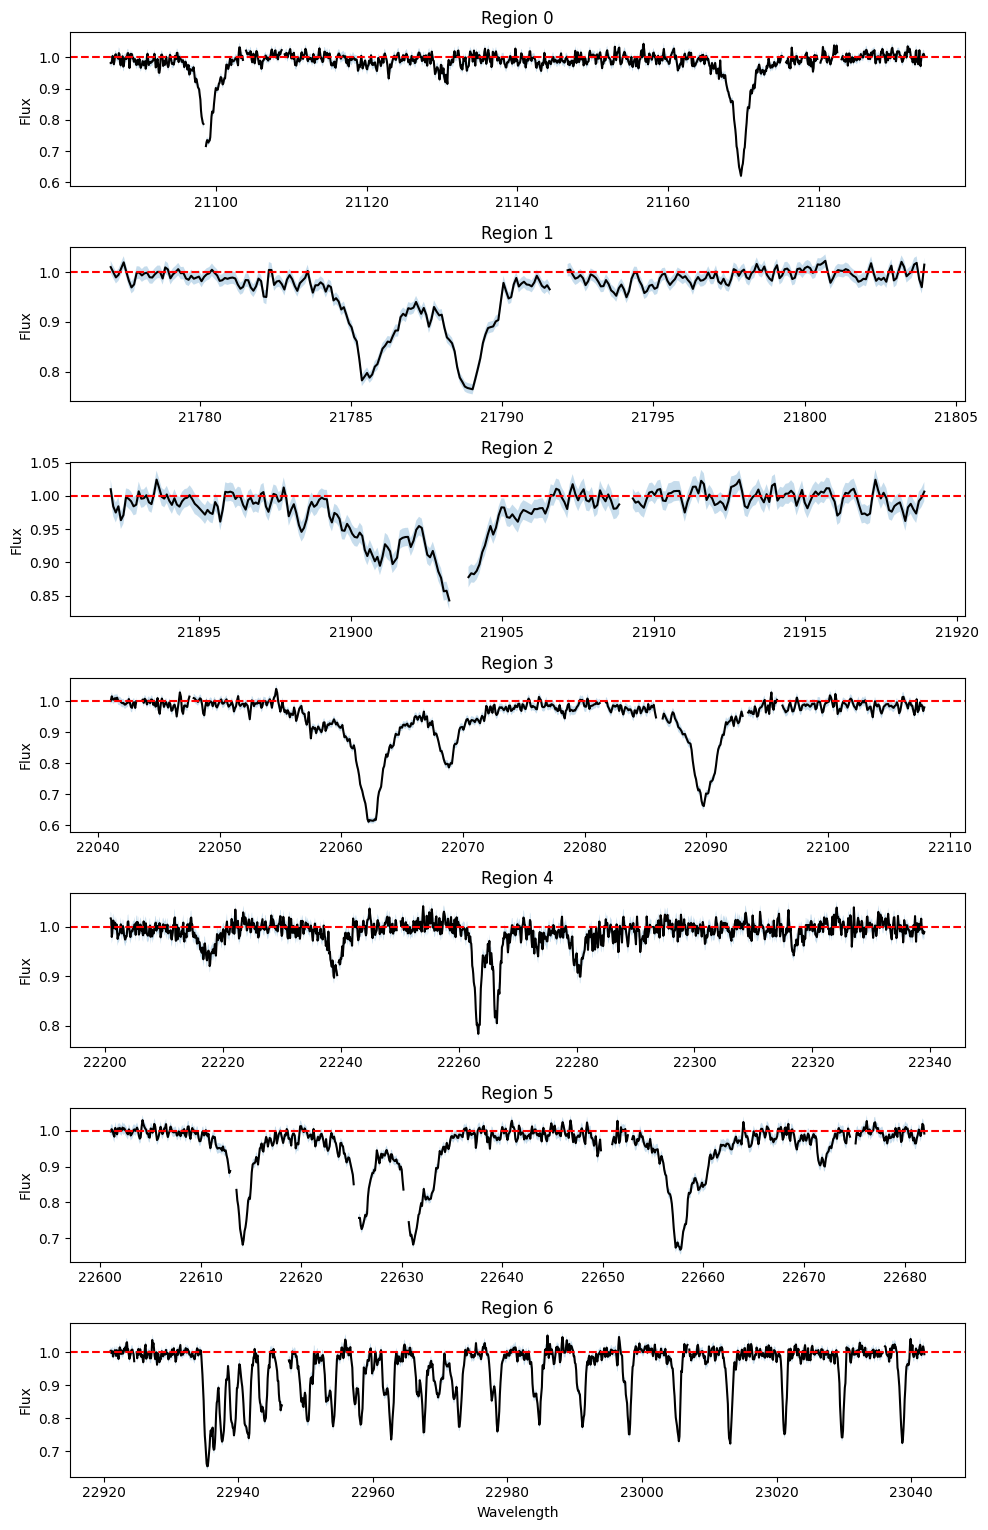

In [1176]:
fig, axes = plt.subplots(len(testdata.regions), 1, figsize=(10, 2.2 * len(testdata.regions)))

if len(testdata.regions) == 1:
    axes = [axes]

for ax, r in zip(axes, testdata.regions):
    x, y, yerr = testdata.get_region(r)
    ax.plot(x, y, color="black")
    ax.fill_between(x, y - yerr, y + yerr, alpha=0.25)
    ax.set_title(f"Region {r}")
    ax.set_ylabel("Flux")
    ax.axhline(1,color='r',linestyle='--')

axes[-1].set_xlabel("Wavelength")
plt.tight_layout()
plt.show()

In [1177]:
moognn = MoogStokesNN(nn_models_dir="data/", regions=range(7))

In [1127]:
stage1_out = run_stage_raw(
    basename=basename,
    moognn=moognn,
    data_path=data_path,
    regions=[0, 1, 2, 3, 4, 5, 6],
    fixed_params={},                 # all 5 parameters free
    stage_label="all regions",
    nwalkers=16,
    nsteps=600,
    scale_discard=400,
    scale_thin=5,
)


[Nyquist sampling] Factor applied: 1. Old SNR = 82.07247593480383
[Nyquist sampling] Factor applied: 1. New SNR = 82.07247593480383


100%|██████████████████████████████████████████████████████████████████████████████████████████| 600/600 [01:58<00:00,  5.05it/s]


[yerr rescaled] Factor applied: 2.573413490613843. Total scaling so far: 2.573413490613843


100%|██████████████████████████████████████████████████████████████████████████████████████████| 600/600 [01:42<00:00,  5.86it/s]


2.955484235405934


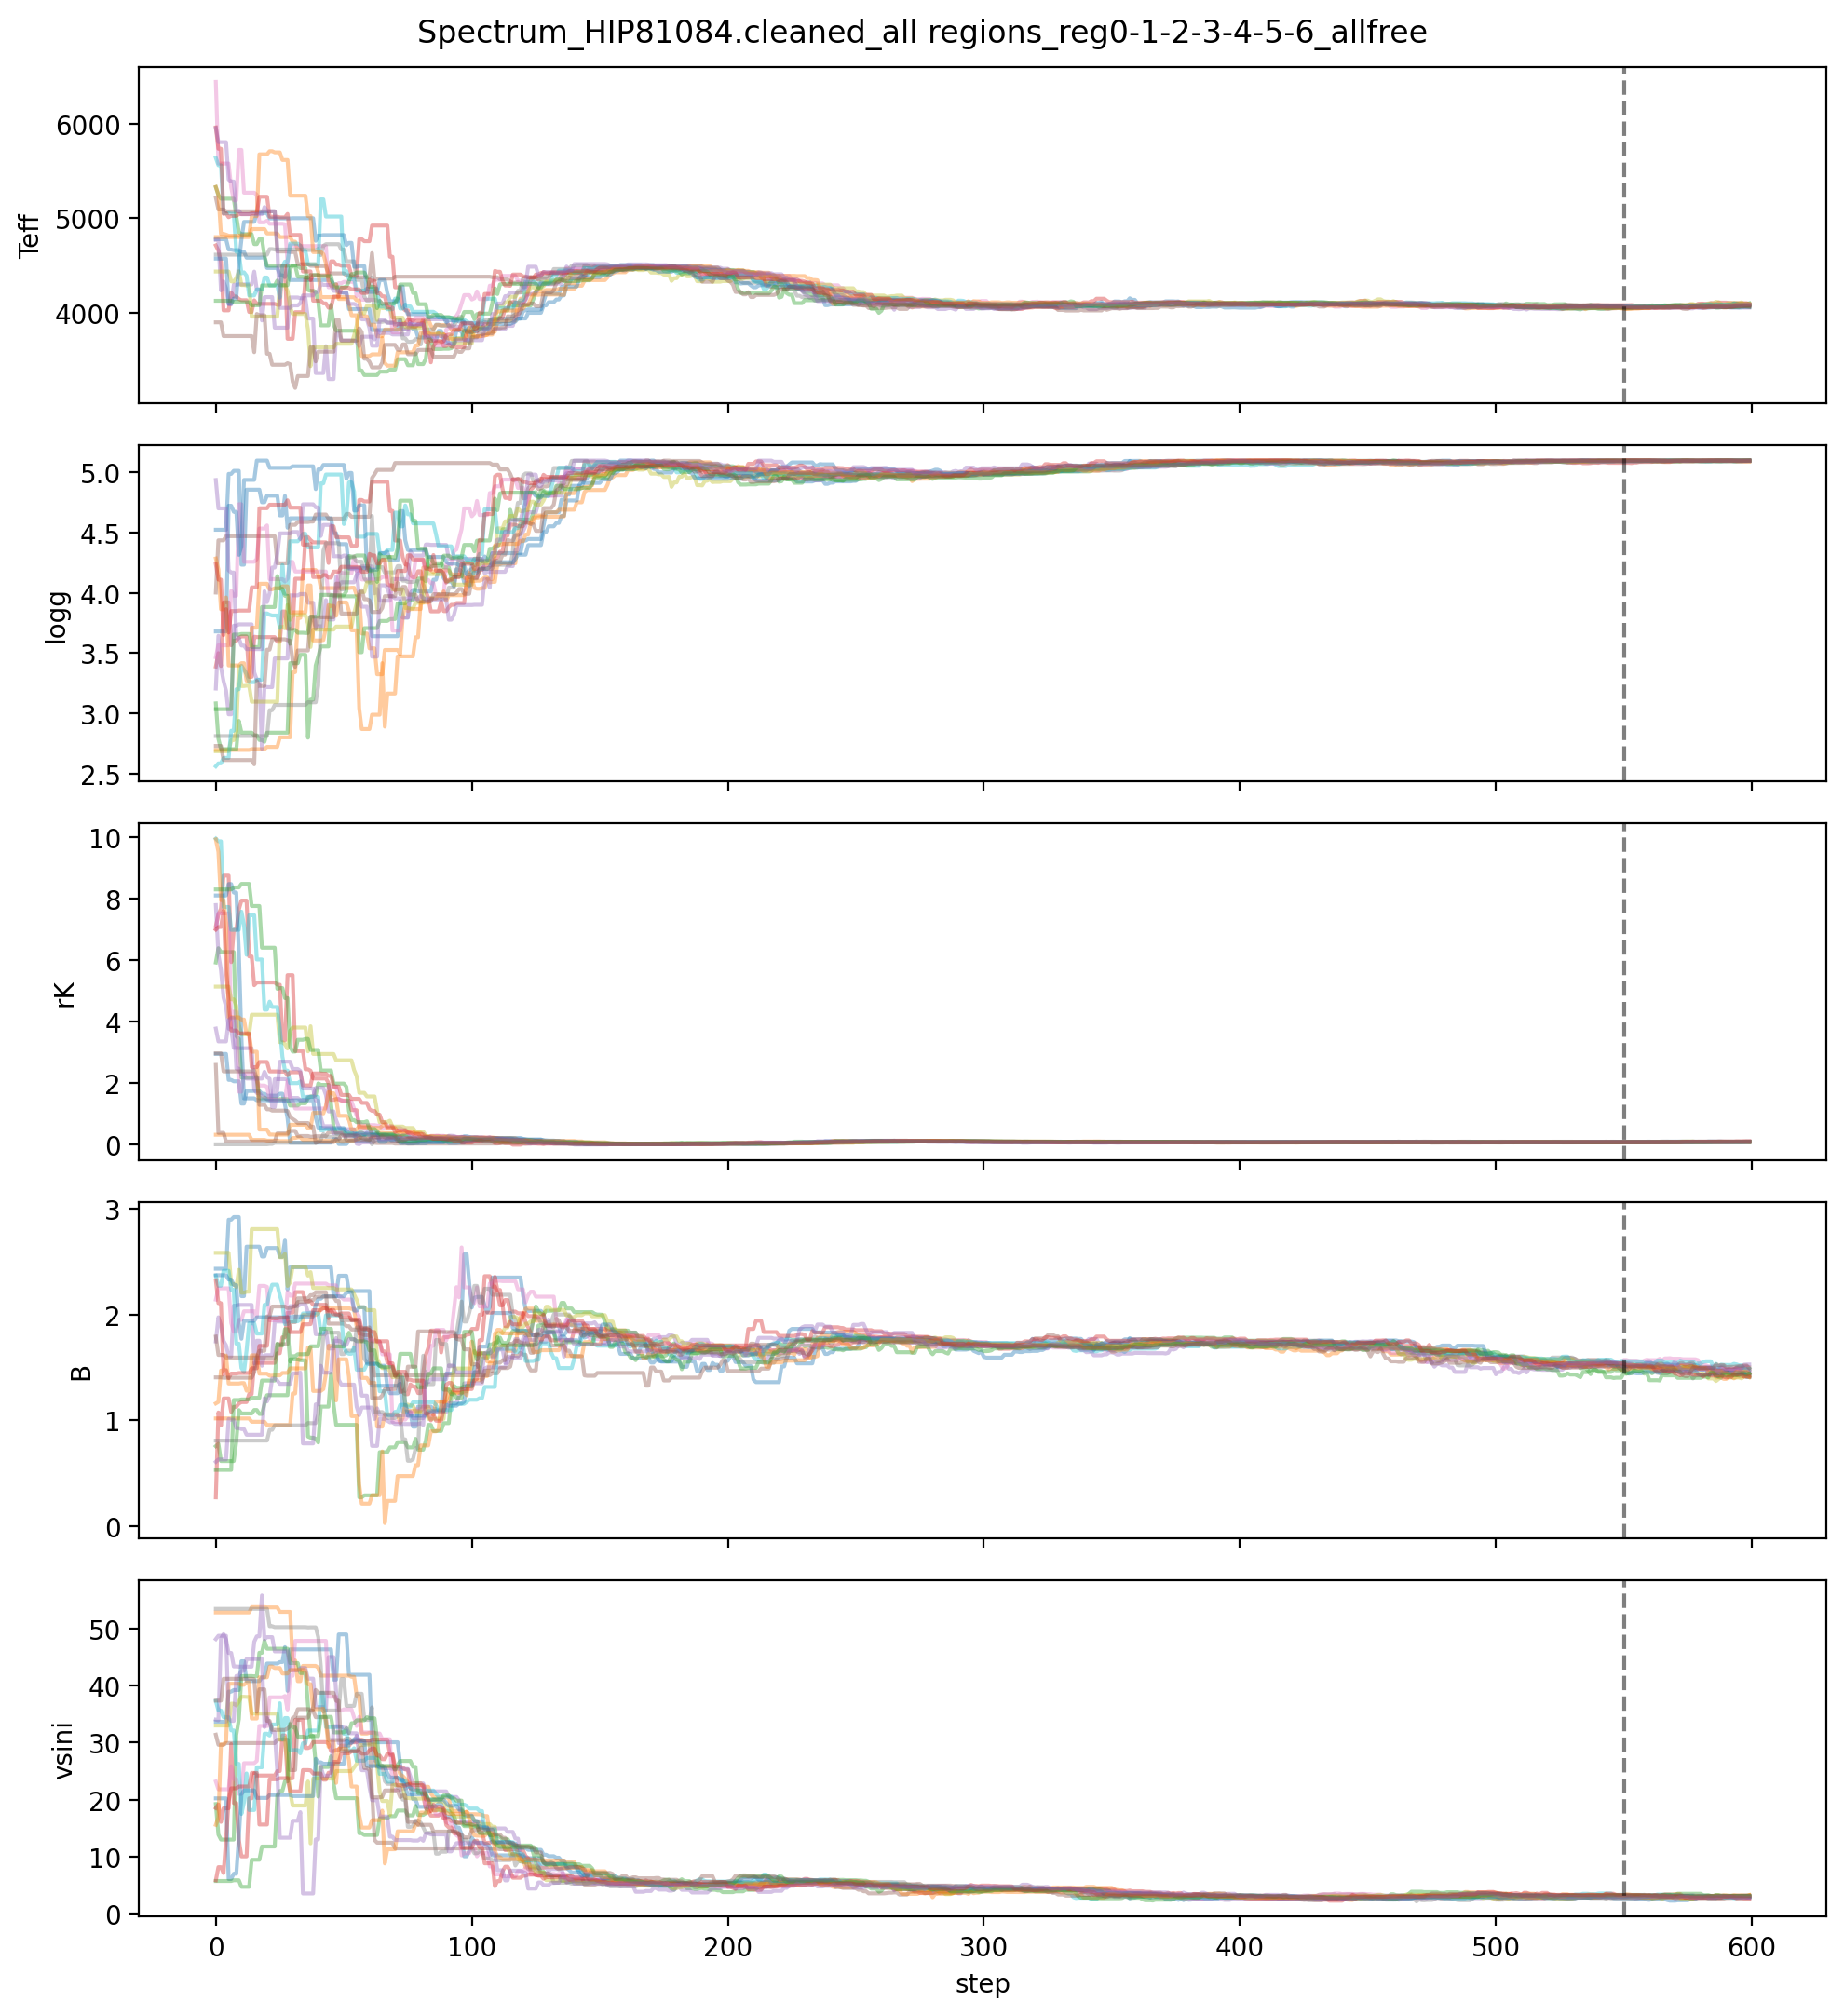

In [1128]:
out1 = postprocess_stage_result(
    stage1_out,
    moognn=moognn,
    data_path=data_path,
    discard=550,
    thin=5,
)

vsini_stage1 = out1["values"]["vsini"]
print(vsini_stage1)

display(Image(out1["trace_plot"]))


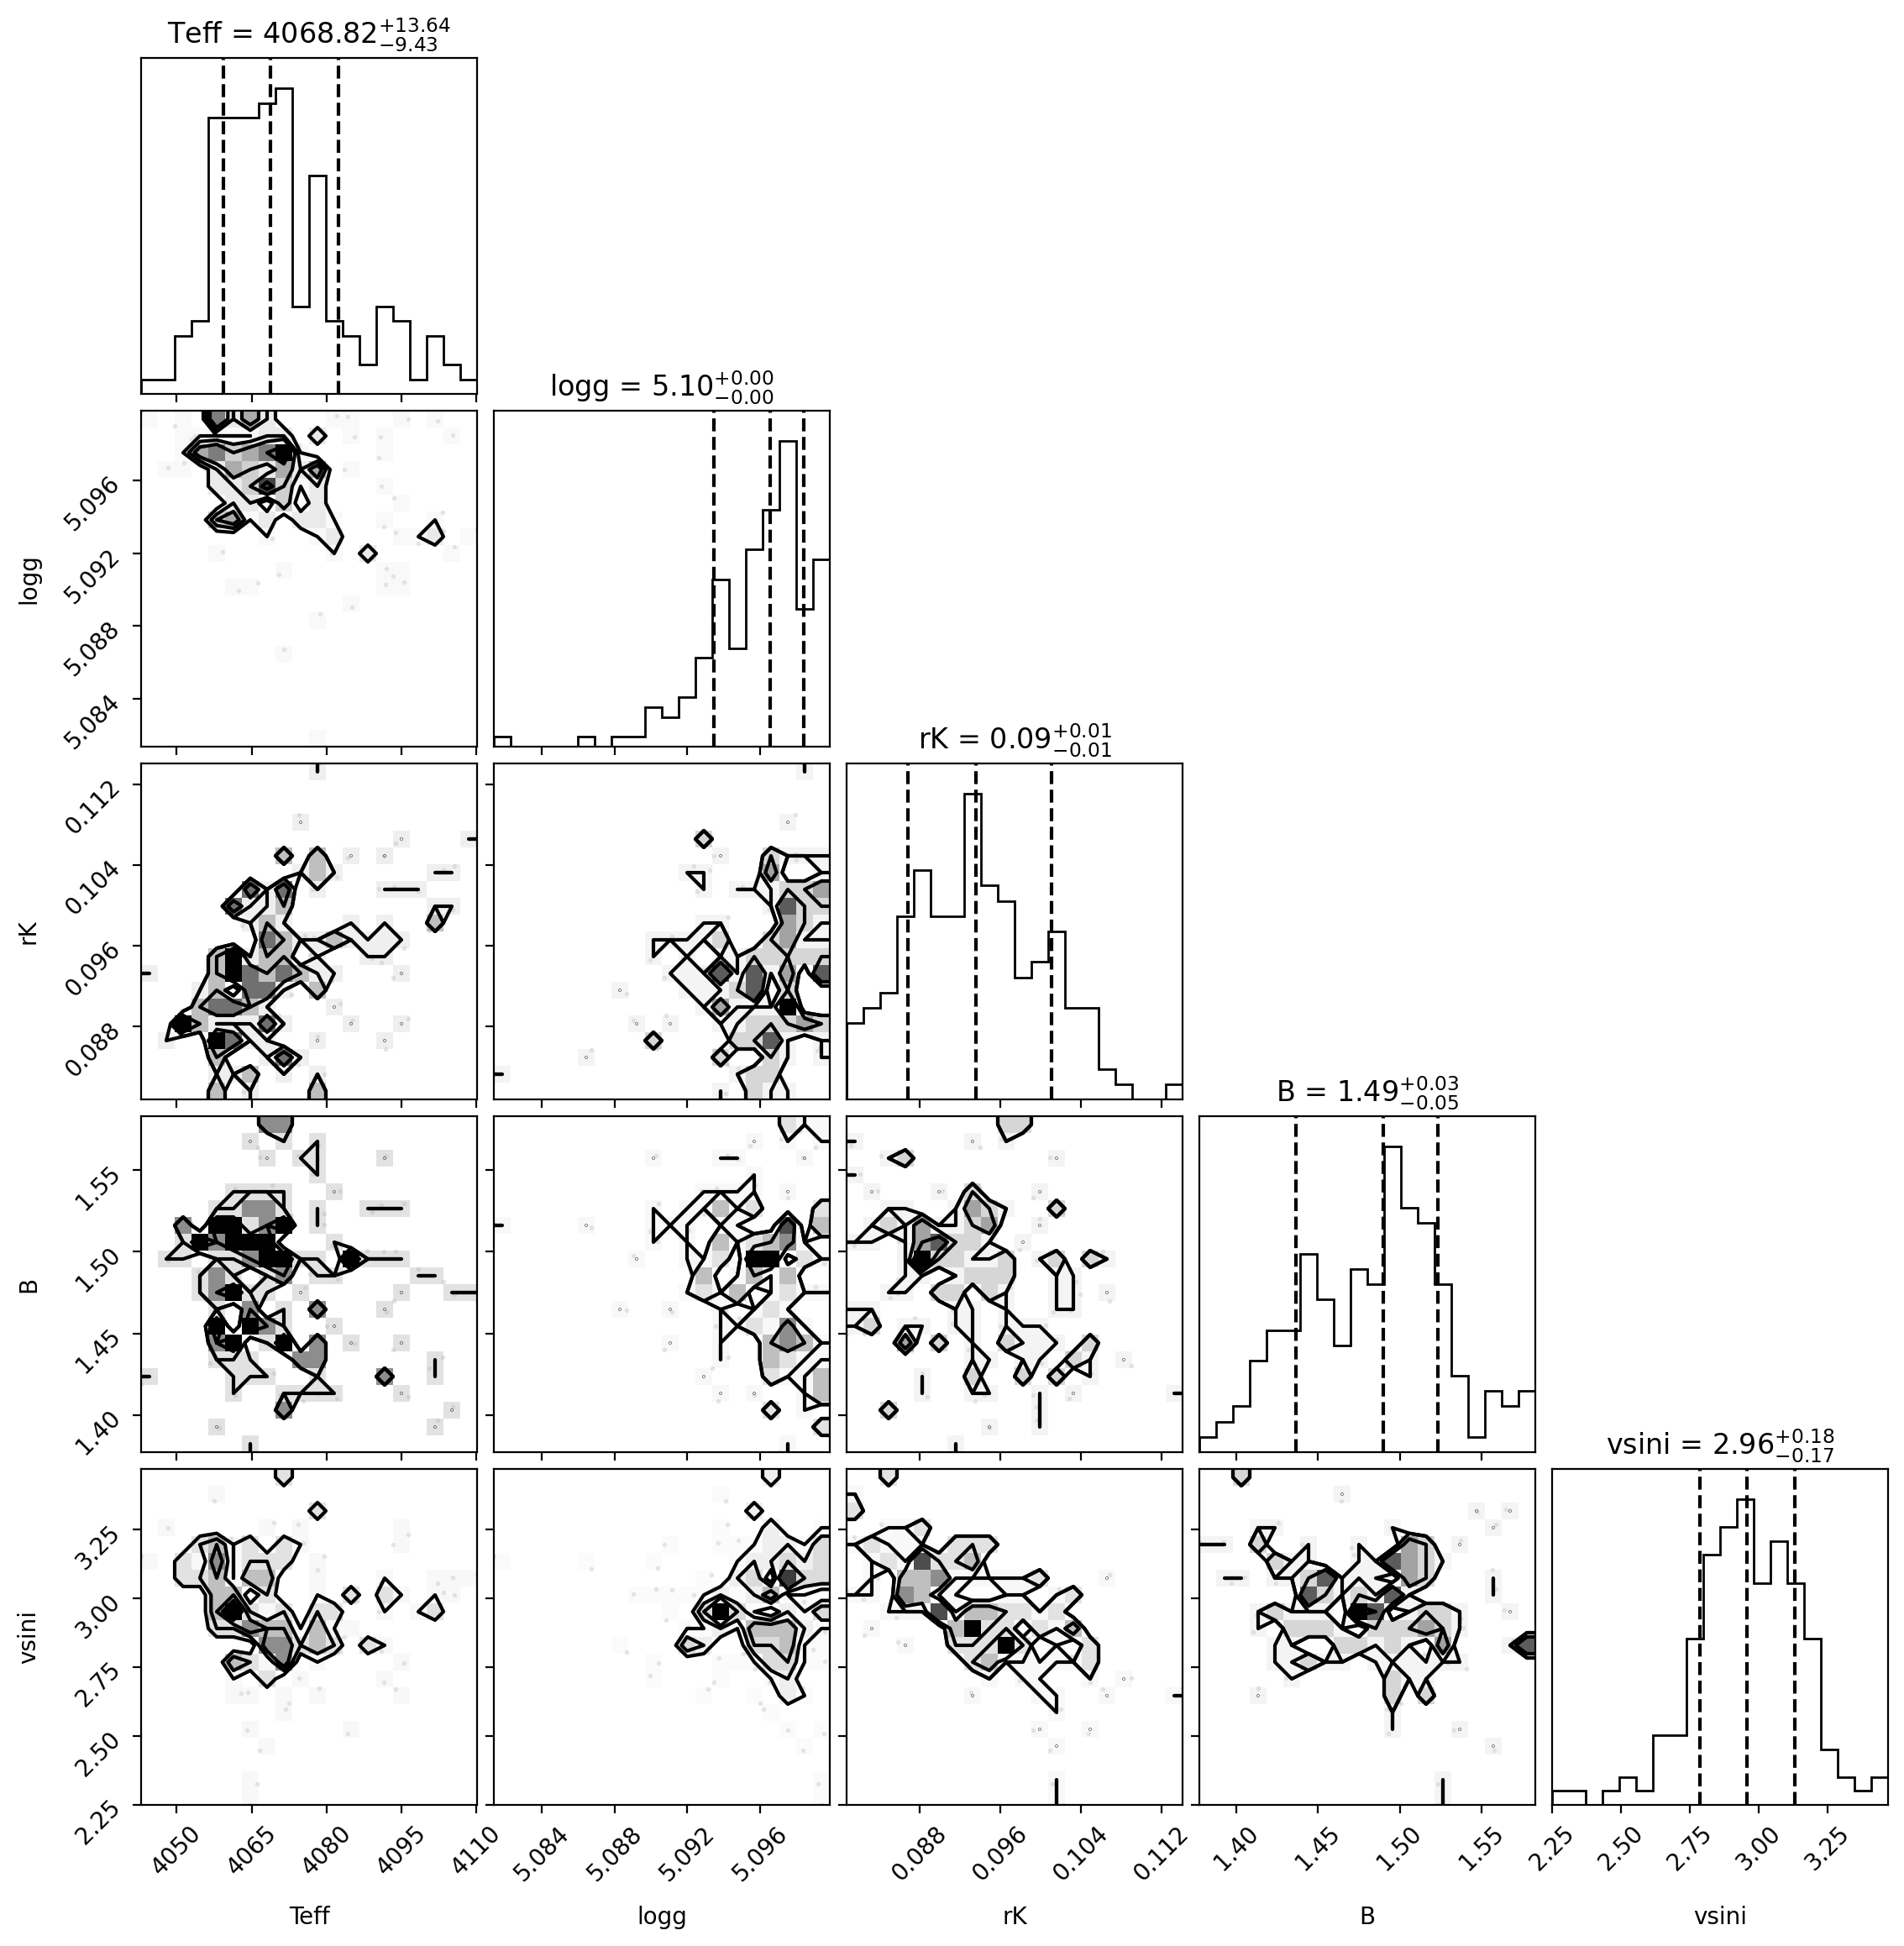

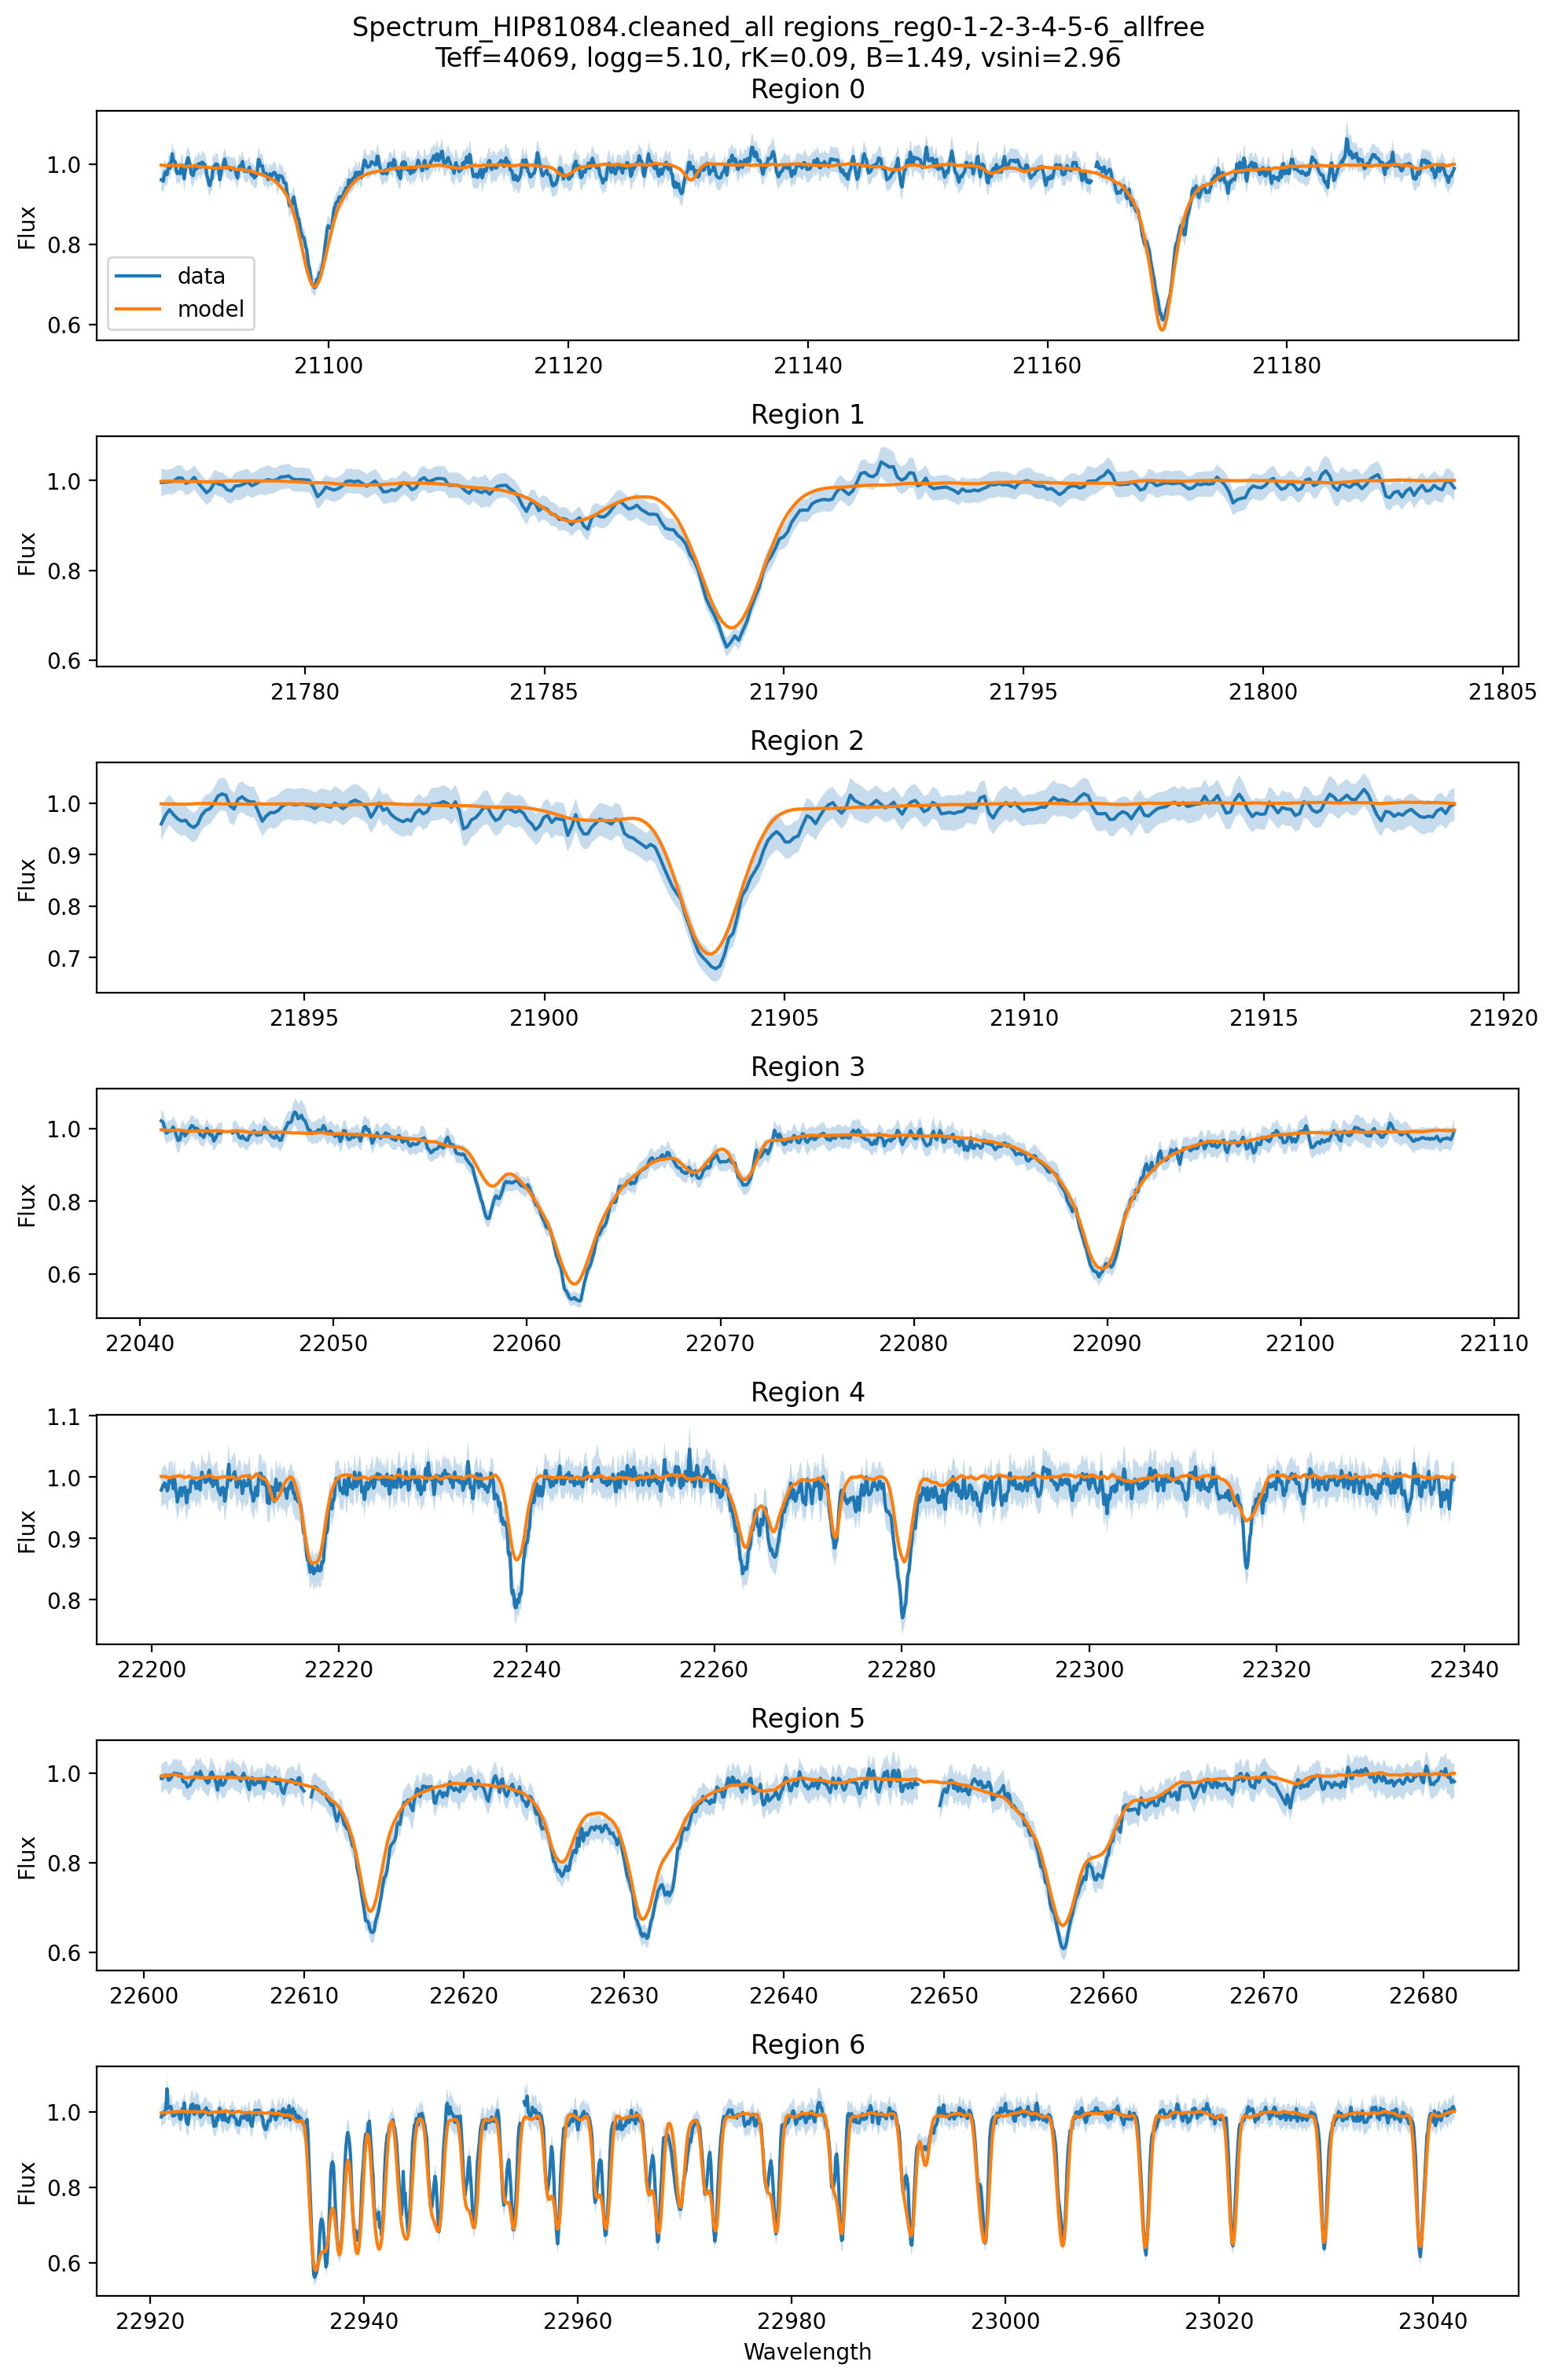

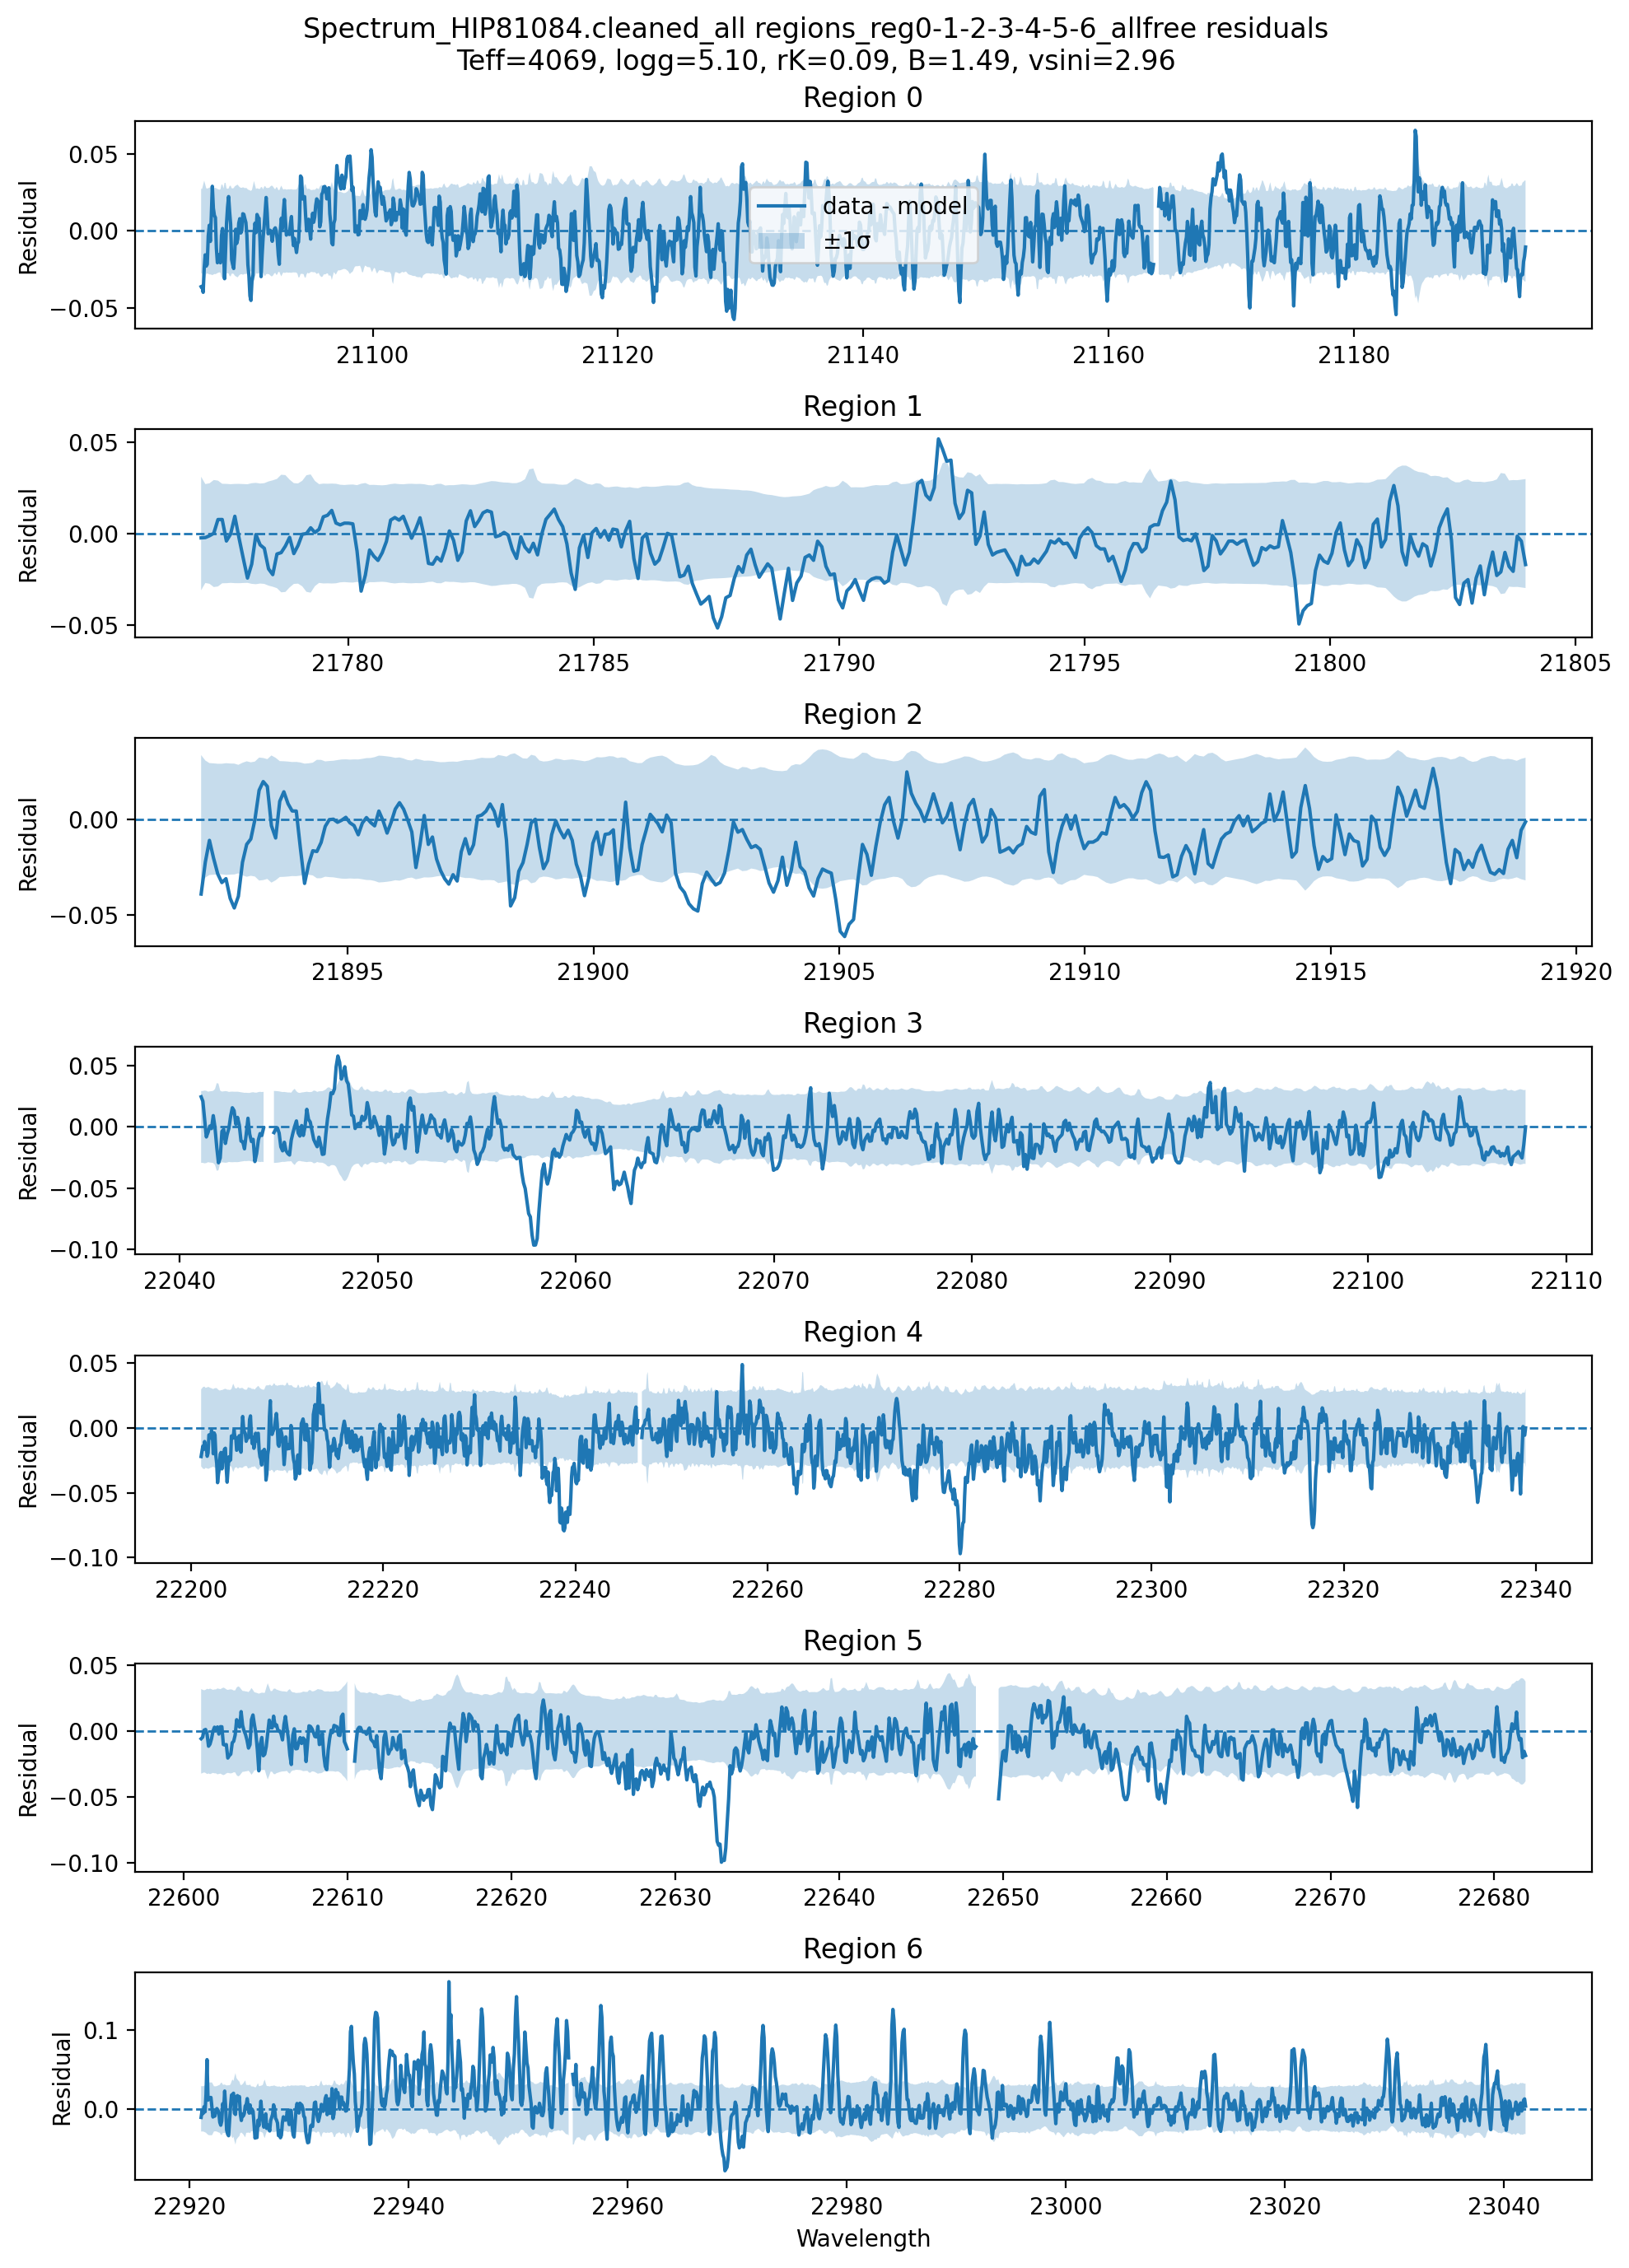

In [1129]:
display(Image(out1["corner_plot"]))
display(Image(out1["bestfit_plot"]))
display(Image(out1["residual_plot"]))


In [1181]:
stage2_out = run_stage_raw(
    basename=basename,
    moognn=moognn,
    data_path=data_path,
    regions=[0, 1, 2, 3, 4, 5],
    fixed_params= {"vsini": 12.0},#{},# {"vsini": vsini_stage1}, #vsini_stage1
    stage_label="stage 2 no-lit high vsini ", #"stage2_fix_vsini no region 0 renorm"
    nwalkers=16,
    nsteps=600,
    scale_discard=400,
    scale_thin=5,
)

[Nyquist sampling] Factor applied: 1. Old SNR = 70.4529656964564
[Nyquist sampling] Factor applied: 1. New SNR = 70.4529656964564


100%|██████████████████████████████████████████████████████████████████████████████████████████| 600/600 [01:29<00:00,  6.73it/s]


[yerr rescaled] Factor applied: 1.2249174555827245. Total scaling so far: 1.2249174555827245


100%|██████████████████████████████████████████████████████████████████████████████████████████| 600/600 [01:25<00:00,  6.98it/s]


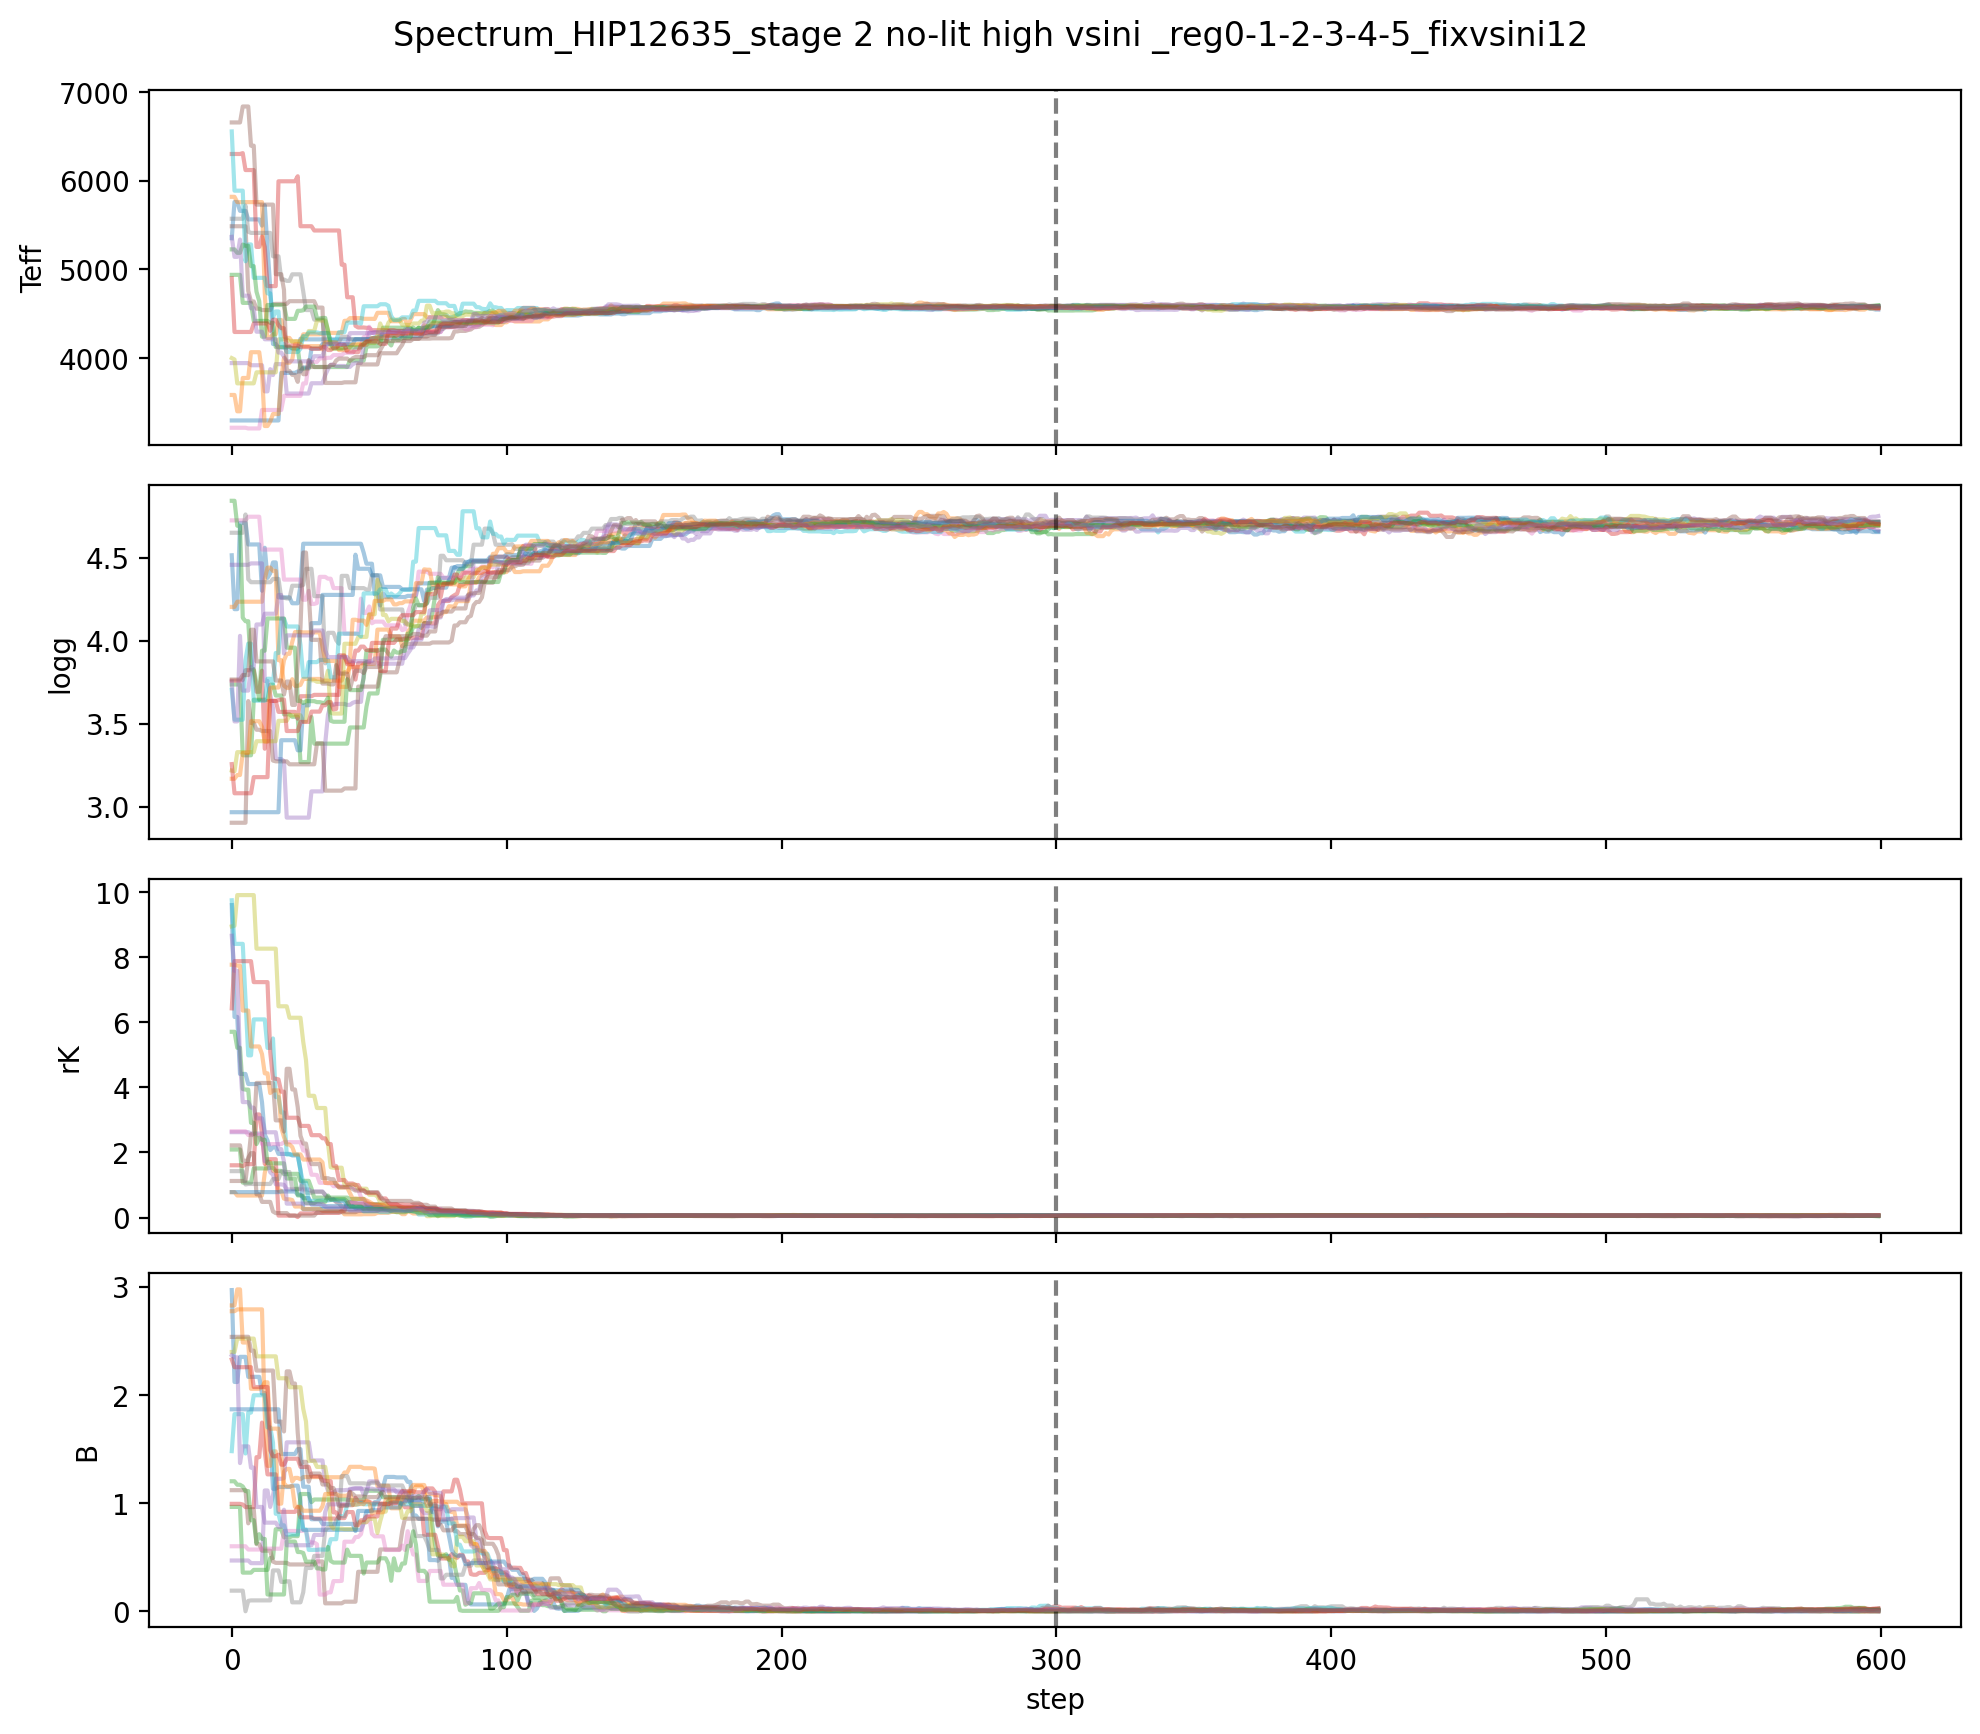

In [1182]:
out2 = postprocess_stage_result(
    stage2_out,
    moognn=moognn,
    data_path=data_path,
    discard=300,
    thin=5,
)

display(Image(out2["trace_plot"]))


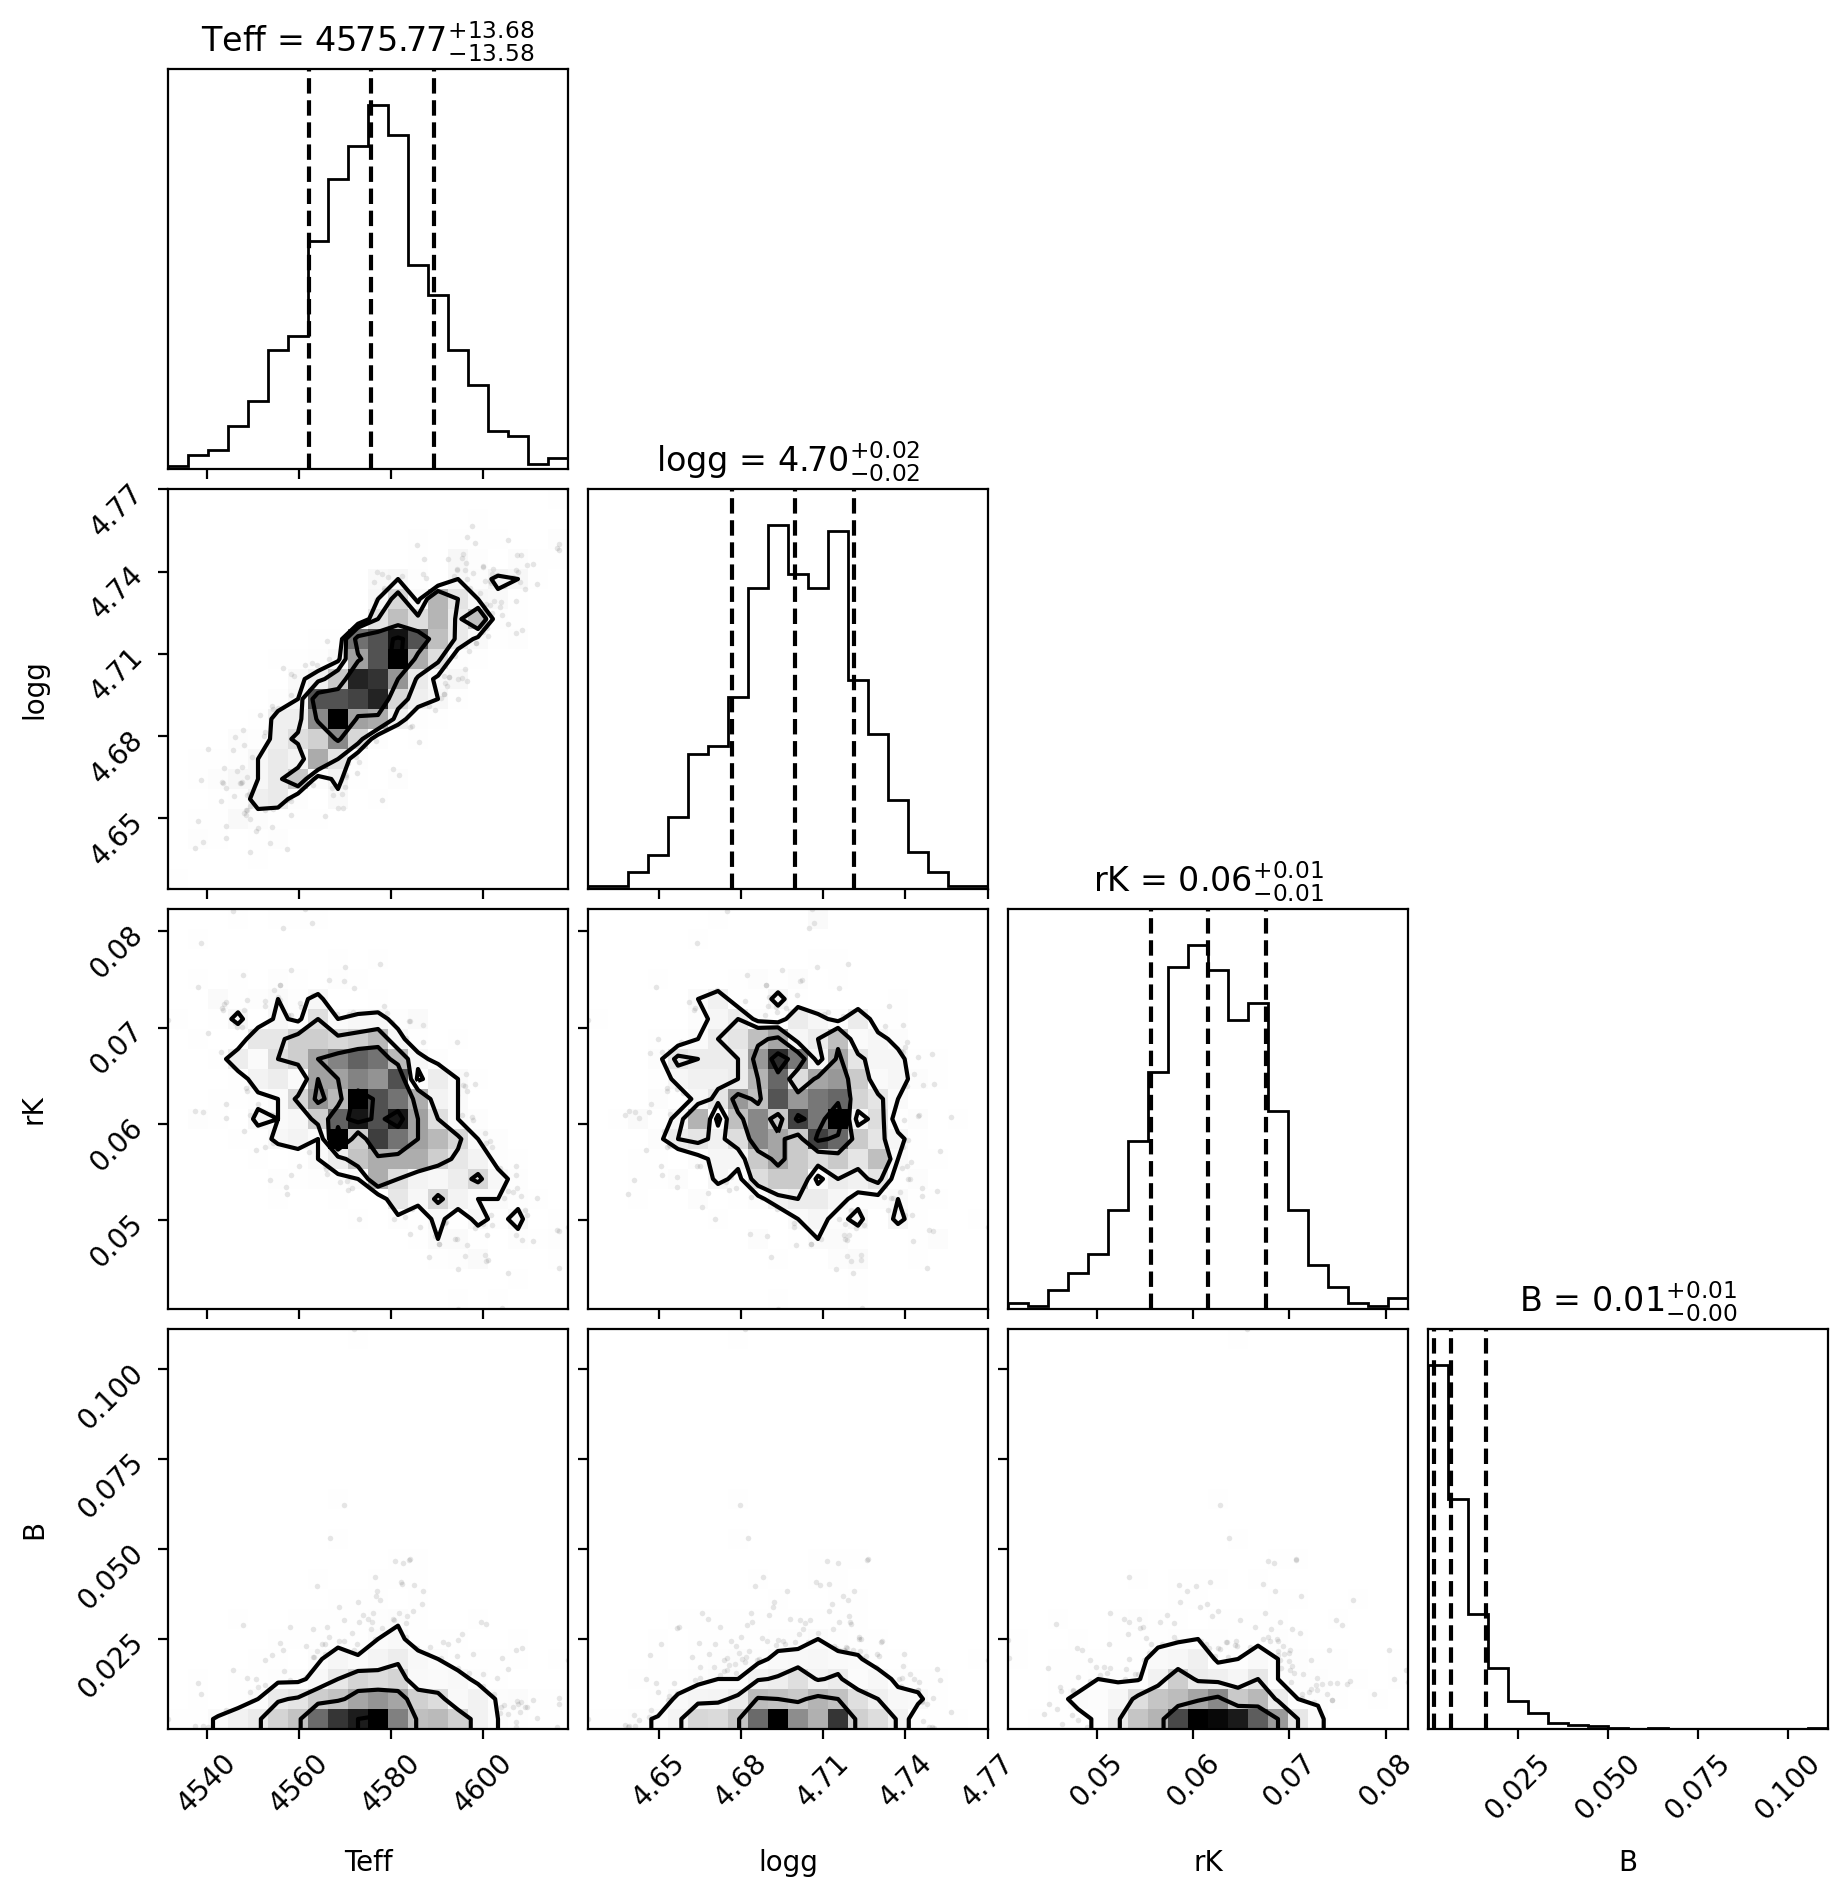

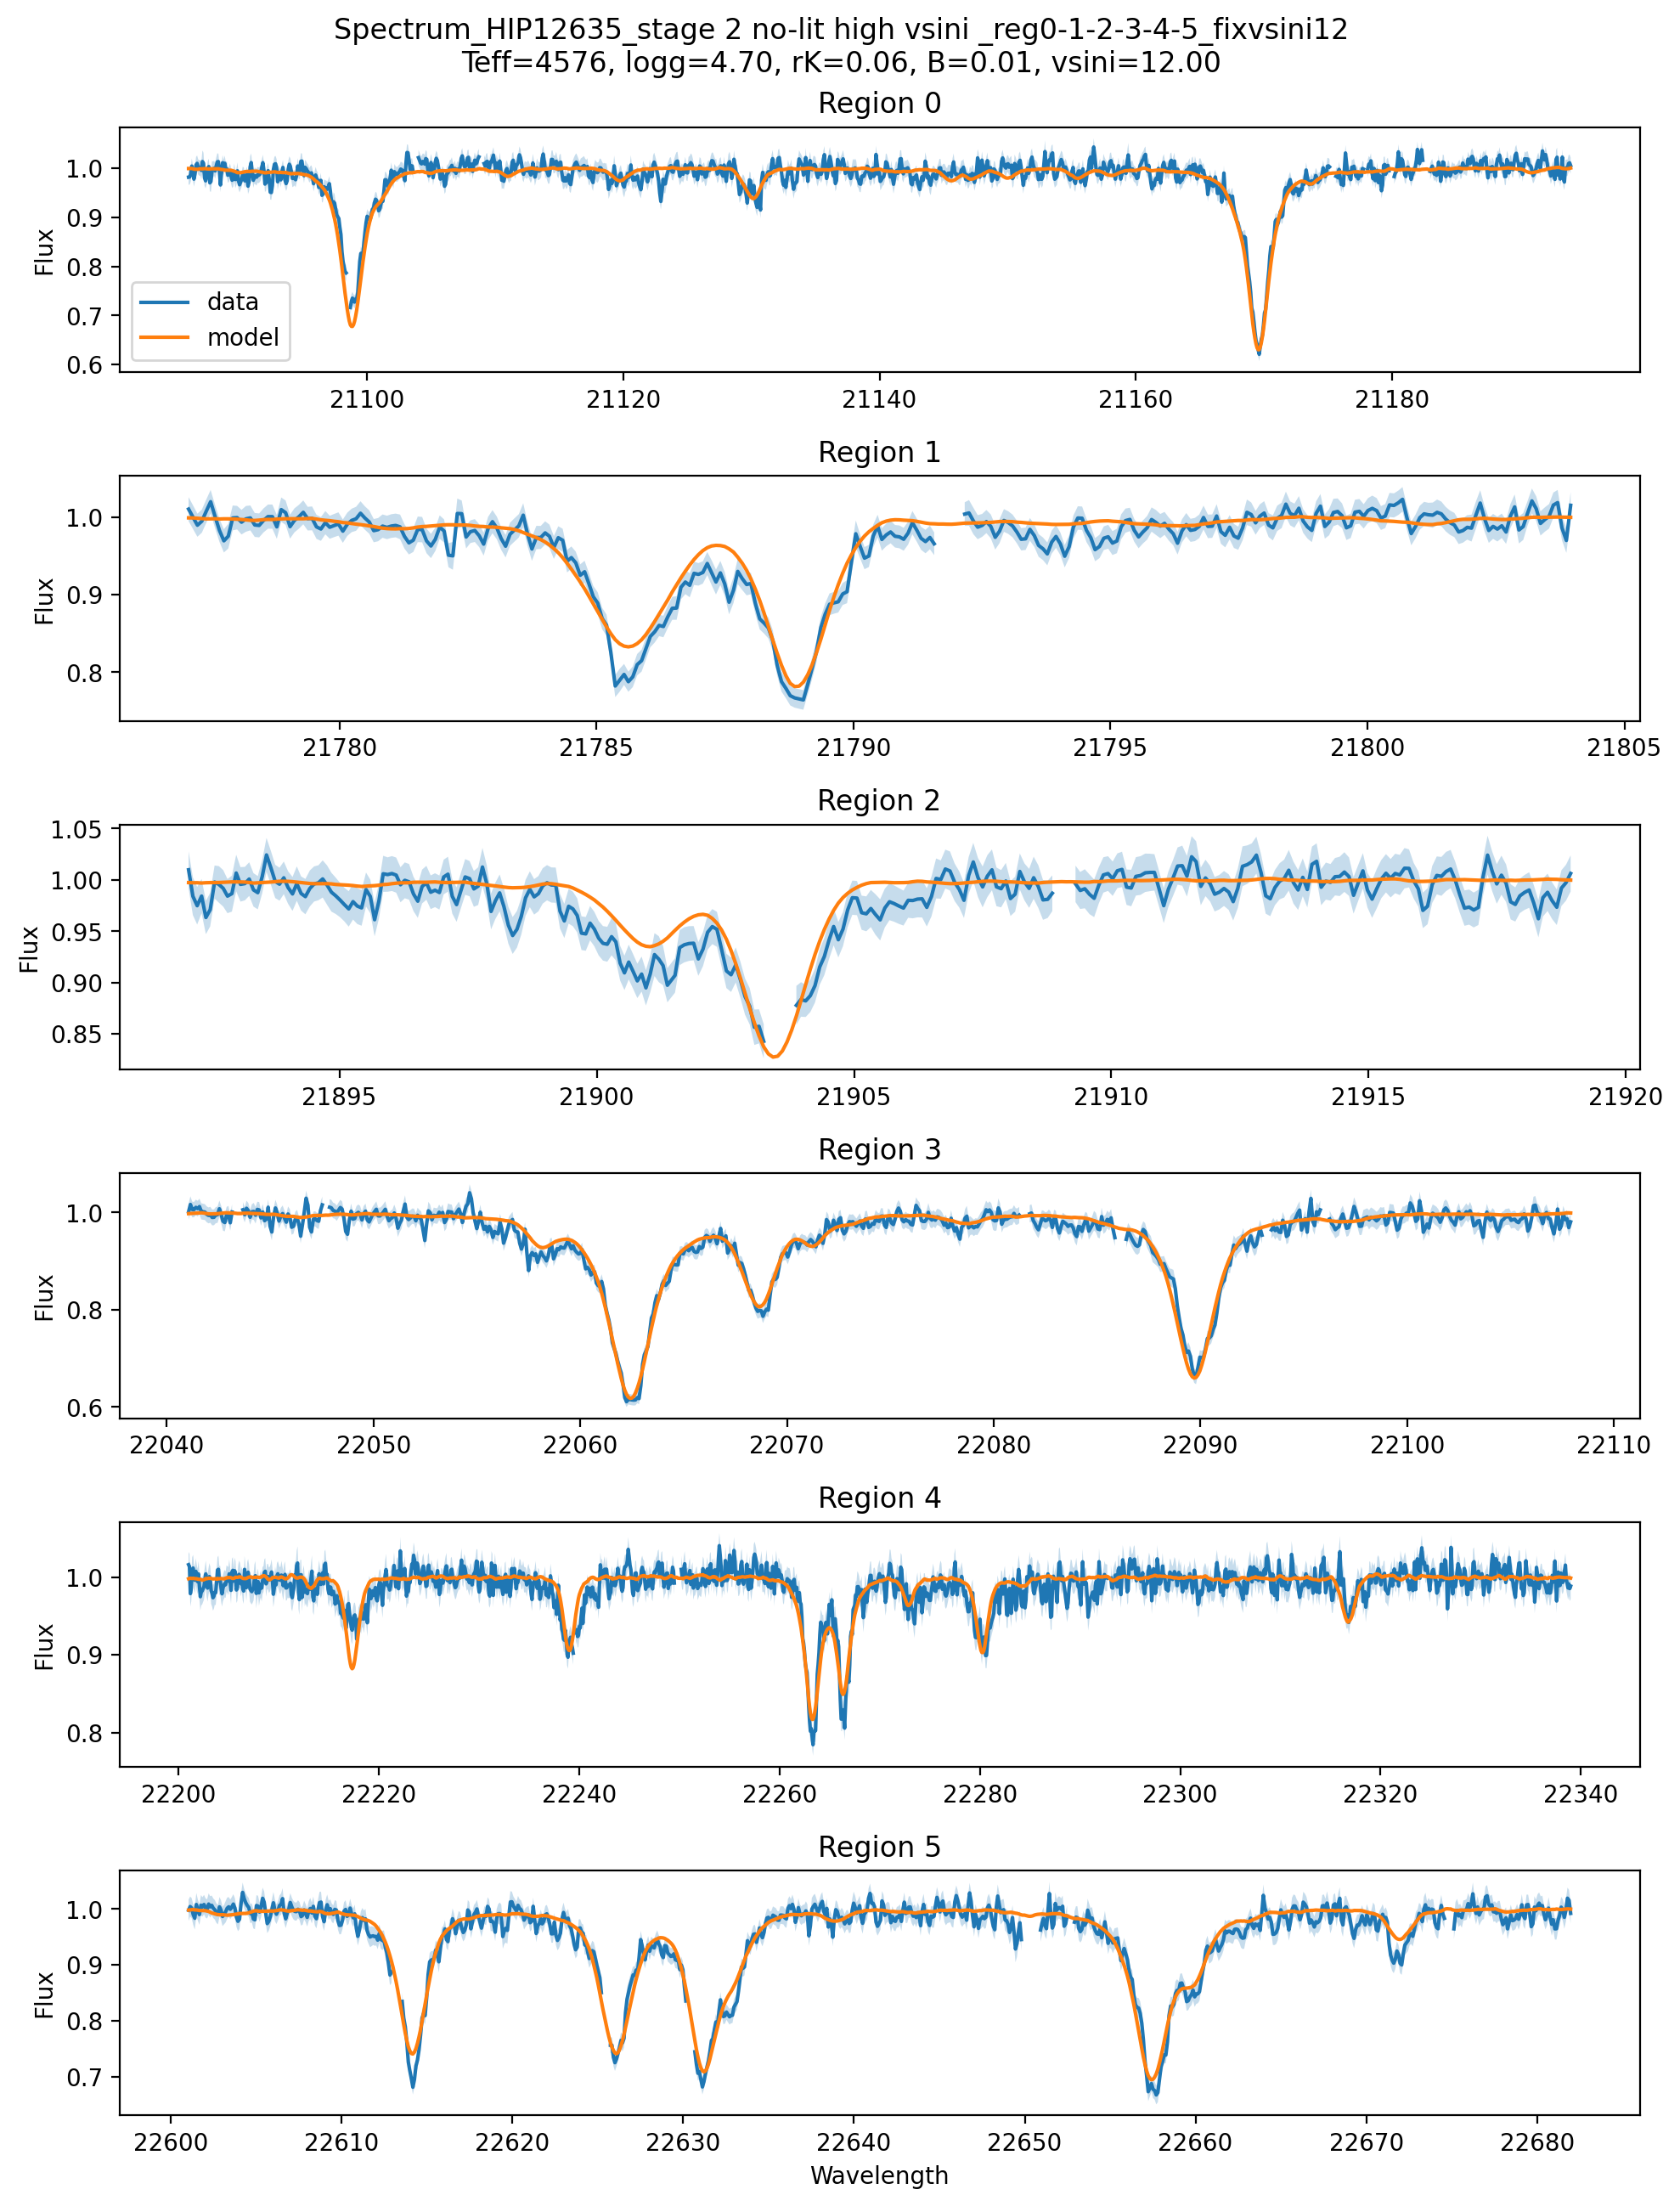

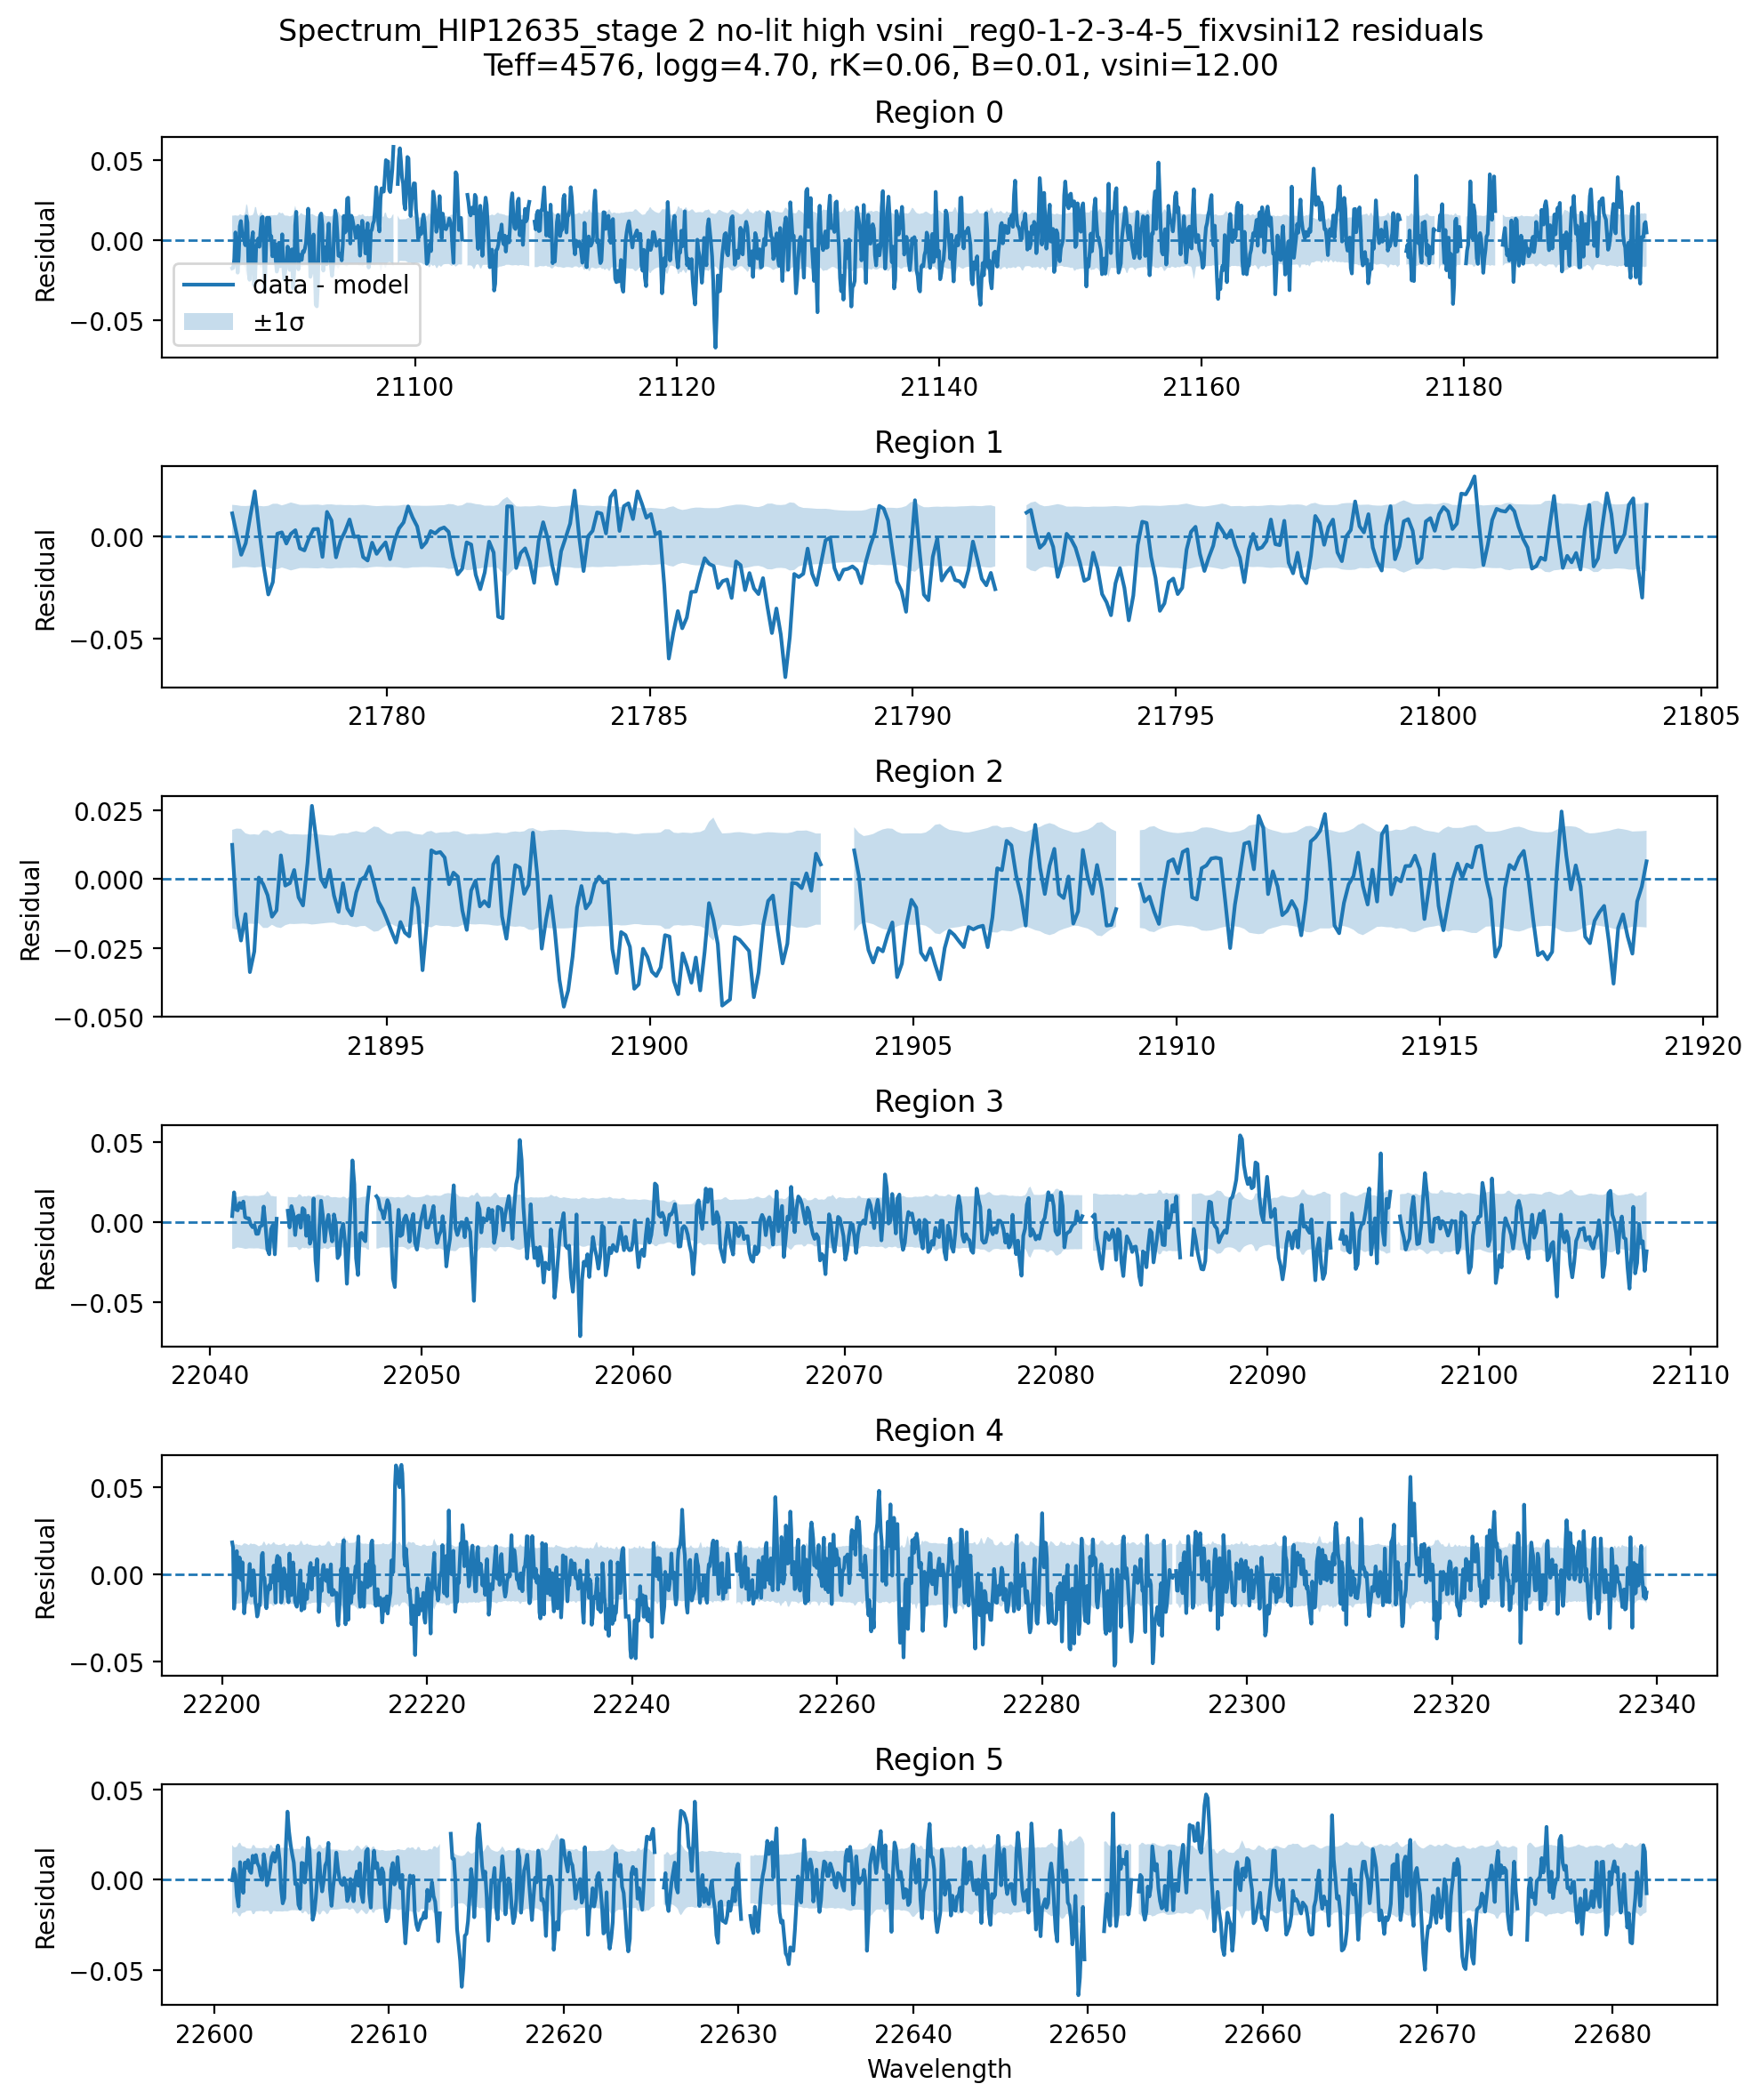

In [1183]:
display(Image(out2["corner_plot"]))
display(Image(out2["bestfit_plot"]))
display(Image(out2["residual_plot"]))
